# 04 - Modelado: ARIMA benchmark + 3 modelos de ML

**Objetivo:** Entrenar y evaluar cuatro modelos de pronóstico de inflación mensual bajo un esquema de validación walk-forward con ventana expandible, para horizontes h = 1, 3, 6 y 12 meses.

**Input:** `data/processed/features.csv` — 395 observaciones × 117 features + target (`inflation_mom`).

**Outputs:**
- `models/best_<modelo>_h<k>.joblib` — modelos entrenados sobre la ventana final (para inferencia futura).
- `models/best_model_per_horizon.json` — metadata del modelo ganador por horizonte.
- `models/walkforward_predictions.csv` — predicciones out-of-sample de cada modelo × horizonte.
- `models/metrics_by_horizon.csv` — métricas RMSE, MAE y R² por modelo × horizonte.
- Figuras en `figures/` (métricas por horizonte, predicho vs real, residuos).

**Metodología resumida:**

1. **Alineación X ↔ y por horizonte.** Como los features ya están rezagados (solo usan información hasta *t-1*), para obtener un pronóstico a *h* meses desde la última información disponible se empareja `X[D]` con `y[D + h − 1]`. Para h=1 la alineación es natural; para h>1 se aplica `shift(-(h-1))` sobre el target.

2. **Walk-forward expanding window.**
   - Entrenamiento inicial: feb-1993 → dic-2010 (≈216 observaciones).
   - Evaluación: ene-2011 en adelante.
   - Re-entrenamiento cada 6 meses (no cada mes) como compromiso entre rigor metodológico y costo computacional. El modelo se mantiene fijo durante los 6 meses intermedios, simulando una práctica operativa realista.

3. **Modelos comparados.**
   - **ARIMA(1,1,1)** — benchmark econométrico univariado sobre la serie de inflación. No usa los features macroeconómicos; su rol es servir como línea base clásica.
   - **Elastic Net** — regularización lineal que maneja la fuerte multicolinealidad entre predictores (PPI, M2, Retail Sales y Gold están correlacionados > 0.9 en niveles).
   - **Random Forest** — ensamble no lineal basado en bagging de árboles.
   - **XGBoost** — boosting sobre árboles, con evidencia de desempeño superior en períodos de alta volatilidad inflacionaria (Naghi et al., 2024).

4. **Hiperparámetros:** se usan defaults razonables documentados en cada celda, sin tuning exhaustivo. Un refinamiento por grid-search se reserva para trabajo futuro; la simplicidad actual favorece reproducibilidad y transparencia.

5. **Métricas:** RMSE, MAE y R² calculadas sobre todas las predicciones out-of-sample de la ventana walk-forward.

6. **Análisis pre/post COVID:** las métricas se recalculan segmentando en marzo-2020 para evaluar si los modelos capturan el quiebre estructural del régimen inflacionario post-pandemia.

## 1. Setup

In [1]:
import json
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.linear_model import ElasticNet
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.arima.model import ARIMA
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")  # ARIMA y sklearn emiten warnings repetitivos
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

# Reproducibilidad
SEED = 42
np.random.seed(SEED)

# Rutas
ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
PATH_FEATURES = ROOT / 'data' / 'processed' / 'features.csv'
PATH_MODELS = ROOT / 'models'
PATH_FIGURES = ROOT / 'figures'
PATH_MODELS.mkdir(exist_ok=True)
PATH_FIGURES.mkdir(exist_ok=True)

# Constantes del experimento
HORIZONS = [1, 3, 6, 12]
INITIAL_TRAIN_END = '2010-12-01'   # fin del primer bloque de entrenamiento
REFIT_EVERY_N_MONTHS = 6           # paso del walk-forward (re-entrenar cada 6 meses)
COVID_SPLIT = '2020-03-01'         # quiebre estructural para análisis pre/post

print(f"Horizontes: {HORIZONS}")
print(f"Fin del train inicial: {INITIAL_TRAIN_END}")
print(f"Re-entrenamiento cada {REFIT_EVERY_N_MONTHS} meses")

Horizontes: [1, 3, 6, 12]
Fin del train inicial: 2010-12-01
Re-entrenamiento cada 6 meses


## 2. Cargar dataset de features

In [2]:
df = pd.read_csv(PATH_FEATURES, index_col='date', parse_dates=True).sort_index()

X_all = df.drop(columns='inflation_mom')
y_all = df['inflation_mom']

print(f"Features: {X_all.shape}")
print(f"Target : {y_all.shape}")
print(f"Periodo: {df.index.min():%Y-%m} → {df.index.max():%Y-%m}")
print(f"Nulos  : {df.isna().sum().sum()}")

Features: (395, 117)
Target : (395,)
Periodo: 1993-02 → 2025-12
Nulos  : 0


## 3. Alineación X ↔ y por horizonte

Función utilitaria que, para un horizonte `h`, produce pares `(X[D], y[D + h − 1])` descartando las últimas observaciones donde el target desplazado no existe.

**Convención del horizonte:** los features en la fila `D` usan información hasta `D − 1` (todos están rezagados). Por tanto, la pareja natural `(X[D], y[D])` ya es un pronóstico a un mes: predice la inflación de `D` usando info hasta `D − 1`. Para extender a `h` meses, se desplaza el target por `−(h−1)`.

- `h = 1` → sin desplazamiento.
- `h = 3` → `y.shift(-2)`: `X[D]` se empareja con `y[D+2]`.
- `h = 6` → `y.shift(-5)`.
- `h = 12` → `y.shift(-11)`.

In [3]:
def align_for_horizon(X: pd.DataFrame, y: pd.Series, h: int):
    """Devuelve (X, y) alineados para predecir inflación h meses adelante.

    X.iloc[i] se empareja con y.iloc[i + h - 1]. Las últimas h-1 filas de X
    se descartan porque su target desplazado queda fuera del rango disponible.
    """
    shift = -(h - 1)
    y_shifted = y.shift(shift) if shift < 0 else y.copy()
    mask = y_shifted.notna()
    return X.loc[mask].copy(), y_shifted.loc[mask].copy()


# Sanity check sobre todos los horizontes
print(f"{'h':>3} | {'filas_X':>8} | {'filas_y':>8} | {'primera fecha X':>18} | {'última fecha X':>18}")
print("-" * 70)
for h in HORIZONS:
    Xh, yh = align_for_horizon(X_all, y_all, h)
    print(f"{h:>3} | {len(Xh):>8} | {len(yh):>8} | {Xh.index.min():%Y-%m  (fila {0})   } | {Xh.index.max():%Y-%m  (fila {len(Xh)-1})}")

  h |  filas_X |  filas_y |    primera fecha X |     última fecha X
----------------------------------------------------------------------
  1 |      395 |      395 | 1993-02  (fila 0)    | 2025-12  (fila 394)
  3 |      393 |      393 | 1993-02  (fila 0)    | 2025-10  (fila 392)
  6 |      390 |      390 | 1993-02  (fila 0)    | 2025-07  (fila 389)
 12 |      384 |      384 | 1993-02  (fila 0)    | 2025-01  (fila 383)


## 4. Definición de modelos

Cada modelo se envuelve en una factoría sin estado: al invocarla se obtiene una instancia *fresca* del pipeline, lista para entrenarse. Esto evita contaminación de estado entre folds del walk-forward.

**Elección de hiperparámetros (defaults defendibles):**

- `ElasticNet(alpha=0.01, l1_ratio=0.5)` — penalización moderada; `l1_ratio=0.5` balancea LASSO y Ridge y respeta la motivación de la propuesta. El escalamiento estándar es obligatorio para que la penalización sea comparable entre features.
- `RandomForestRegressor(n_estimators=200, max_depth=10, min_samples_leaf=2)` — 200 árboles es suficiente para estabilizar predicciones; `max_depth=10` evita el sobreajuste típico en datasets pequeños (~250 obs).
- `XGBRegressor(n_estimators=200, max_depth=4, learning_rate=0.05, subsample=0.8)` — parámetros conservadores orientados a evitar sobreajuste: profundidad baja, shrinkage pequeño y submuestreo del 80 %.

No se incluye tuning exhaustivo para no alargar el tiempo de ejecución ni introducir variabilidad por búsqueda aleatoria. La comparación justa se logra con configuraciones razonables y reproducibles (semilla fija).

In [4]:
def make_elasticnet():
    return Pipeline([
        ('scaler', StandardScaler()),
        ('model', ElasticNet(alpha=0.01, l1_ratio=0.5, max_iter=10_000, random_state=SEED)),
    ])

def make_random_forest():
    return RandomForestRegressor(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=2,
        n_jobs=-1,
        random_state=SEED,
    )

def make_xgboost():
    return XGBRegressor(
        n_estimators=200,
        max_depth=4,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        objective='reg:squarederror',
        random_state=SEED,
        n_jobs=-1,
        verbosity=0,
    )

ML_MODELS = {
    'ElasticNet':   make_elasticnet,
    'RandomForest': make_random_forest,
    'XGBoost':      make_xgboost,
}
print("Modelos ML registrados:", list(ML_MODELS.keys()))

Modelos ML registrados: ['ElasticNet', 'RandomForest', 'XGBoost']


## 5. Walk-forward expanding window — modelos ML

Mecánica implementada en `walkforward_ml`:

1. Identifica el índice inicial donde termina el primer train (`INITIAL_TRAIN_END`).
2. Avanza un cursor sobre el conjunto de test en bloques de `REFIT_EVERY_N_MONTHS` meses.
3. En cada cursor, re-entrena el modelo con `X[0:cursor]` y `y[0:cursor]`.
4. Genera predicciones para las siguientes `REFIT_EVERY_N_MONTHS` filas de test, manteniendo el modelo fijo dentro del bloque.
5. Al final, acumula predicciones y fechas reales para el cómputo de métricas.

Sin look-ahead: en el fold cursor=C, el modelo solo ha visto datos hasta índice `C-1` inclusive.

In [5]:
def walkforward_ml(make_model, X, y, initial_train_end, step):
    """Corre walk-forward expanding window con re-entrenamiento cada `step` meses.

    Retorna un DataFrame con columnas ['y_true', 'y_pred'] indexado por fecha.
    """
    # Posición del cursor inicial (última fila del train inicial + 1)
    cutoff_pos = X.index.get_indexer([pd.Timestamp(initial_train_end)], method='bfill')[0]
    if cutoff_pos < 0:
        raise ValueError(f"initial_train_end {initial_train_end} fuera de rango")
    start = cutoff_pos + 1  # primera fila a predecir

    preds_records = []
    cursor = start
    n = len(X)
    while cursor < n:
        model = make_model()
        model.fit(X.iloc[:cursor], y.iloc[:cursor])

        block_end = min(cursor + step, n)
        X_block = X.iloc[cursor:block_end]
        y_block = y.iloc[cursor:block_end]
        y_pred = model.predict(X_block)

        for dt, yt, yp in zip(X_block.index, y_block.values, y_pred):
            preds_records.append({'date': dt, 'y_true': yt, 'y_pred': yp})

        cursor = block_end

    return pd.DataFrame(preds_records).set_index('date')

## 6. Walk-forward — ARIMA benchmark

ARIMA no consume los features macroeconómicos: se entrena sobre la serie `inflation_mom` directamente. La mecánica es equivalente al walk-forward anterior, con el ajuste de que ARIMA produce pronósticos multi-paso vía `model.forecast(steps=h)`.

**Alineación por horizonte para ARIMA:**
- En el cursor `C`, entrenamos sobre `y[0:C]` (información hasta `C−1` inclusive).
- `forecast(h)[h−1]` es el pronóstico para `y[C+h−1]`.
- Dentro del bloque de `step` meses, para predecir `y[t+h−1]` con `t ∈ [C, C+step)`, usamos `forecast(step + h − 1)[(t−C) + (h−1)]`.

De este modo las predicciones de ARIMA y ML comparten las mismas fechas objetivo, haciendo la comparación de métricas directa.

In [6]:
def walkforward_arima(y_full, initial_train_end, step, horizon, order=(1, 1, 1)):
    """Walk-forward ARIMA para un horizonte dado, sin uso de features.

    Nota técnica: `forecast(steps=...)` de statsmodels exige un `int` nativo
    de Python. Un `numpy.int64` hace que el cálculo interno de `end` se
    interprete incorrectamente y lance `ValueError: Prediction must have
    `end` after `start`.` Por eso se castea explícitamente `steps_needed`.
    """
    cutoff_pos = int(y_full.index.get_indexer([pd.Timestamp(initial_train_end)], method='bfill')[0])
    start = cutoff_pos + 1
    n = len(y_full)

    preds_records = []
    cursor = start
    while cursor + horizon - 1 < n:
        train_y = y_full.iloc[:cursor]
        try:
            fitted = ARIMA(train_y, order=order).fit()
        except Exception:
            fitted = None

        block_end = int(min(cursor + step, n - horizon + 1))
        steps_needed = int((block_end - cursor) + (horizon - 1))
        if fitted is not None:
            forecast = fitted.forecast(steps=steps_needed)
        else:
            forecast = pd.Series([y_full.iloc[:cursor].mean()] * steps_needed)

        for j, t in enumerate(range(cursor, block_end)):
            target_idx = t + horizon - 1
            if target_idx >= n:
                break
            preds_records.append({
                'date':   y_full.index[target_idx],
                'y_true': y_full.iloc[target_idx],
                'y_pred': forecast.iloc[j + horizon - 1],
            })

        cursor = block_end

    return pd.DataFrame(preds_records).set_index('date')

## 7. Ejecución del experimento completo

Se recorren los 4 horizontes y para cada uno se entrenan los 4 modelos. Los resultados se almacenan en `all_predictions` (un único DataFrame largo para facilitar la comparación posterior).

In [7]:
all_predictions = []

for h in HORIZONS:
    print(f"\n=== Horizonte h = {h} meses ===")
    Xh, yh = align_for_horizon(X_all, y_all, h)

    # ML
    for name, factory in ML_MODELS.items():
        df_preds = walkforward_ml(factory, Xh, yh, INITIAL_TRAIN_END, REFIT_EVERY_N_MONTHS)
        df_preds['model'] = name
        df_preds['horizon'] = h
        all_predictions.append(df_preds.reset_index())
        rmse = np.sqrt(mean_squared_error(df_preds['y_true'], df_preds['y_pred']))
        print(f"  {name:<13} → {len(df_preds):>4} pred | RMSE {rmse:.4f}")

    # ARIMA (usa solo y_all)
    df_arima = walkforward_arima(y_all, INITIAL_TRAIN_END, REFIT_EVERY_N_MONTHS, h)
    df_arima['model'] = 'ARIMA'
    df_arima['horizon'] = h
    all_predictions.append(df_arima.reset_index())
    rmse = np.sqrt(mean_squared_error(df_arima['y_true'], df_arima['y_pred']))
    print(f"  {'ARIMA':<13} → {len(df_arima):>4} pred | RMSE {rmse:.4f}")

predictions_df = pd.concat(all_predictions, ignore_index=True)
print(f"\nTotal de predicciones acumuladas: {len(predictions_df)}")


=== Horizonte h = 1 meses ===
  ElasticNet    →  180 pred | RMSE 0.3386


  RandomForest  →  180 pred | RMSE 0.2647


  XGBoost       →  180 pred | RMSE 0.2585


  ARIMA         →  180 pred | RMSE 0.2659

=== Horizonte h = 3 meses ===
  ElasticNet    →  178 pred | RMSE 0.3191


  RandomForest  →  178 pred | RMSE 0.2987


...

  XGBoost       →  175 pred | RMSE 0.2970


  ARIMA         →  175 pred | RMSE 0.2698

=== Horizonte h = 12 meses ===
  ElasticNet    →  169 pred | RMSE 0.2581


  RandomForest  →  169 pred | RMSE 0.2969


  XGBoost       →  169 pred | RMSE 0.3010


  ARIMA         →  169 pred | RMSE 0.2756

Total de predicciones acumuladas: 2808


## 8. Métricas por modelo y horizonte

Para cada combinación (modelo, horizonte) se calculan:

- **RMSE** — Raíz del error cuadrático medio, en puntos porcentuales.
- **MAE** — Error absoluto medio, en puntos porcentuales.
- **R²** — Coeficiente de determinación. R² > 0 indica desempeño mejor que predecir siempre la media; R² cercano a 1 indica predicción casi perfecta. Negativo implica que el modelo es peor que la media.

In [8]:
def compute_metrics(df_pred: pd.DataFrame) -> dict:
    return {
        'RMSE': float(np.sqrt(mean_squared_error(df_pred['y_true'], df_pred['y_pred']))),
        'MAE':  float(mean_absolute_error(df_pred['y_true'], df_pred['y_pred'])),
        'R2':   float(r2_score(df_pred['y_true'], df_pred['y_pred'])),
    }

metrics_rows = []
for (model, h), g in predictions_df.groupby(['model', 'horizon']):
    m = compute_metrics(g)
    metrics_rows.append({'model': model, 'horizon': h, 'n': len(g), **m})

metrics_df = pd.DataFrame(metrics_rows).sort_values(['horizon', 'RMSE'])
metrics_df.to_csv(PATH_MODELS / 'metrics_by_horizon.csv', index=False)

print("MÉTRICAS POR MODELO Y HORIZONTE\n" + '=' * 60)
print(metrics_df.round(4).to_string(index=False))

MÉTRICAS POR MODELO Y HORIZONTE
       model  horizon   n   RMSE    MAE      R2
     XGBoost        1 180 0.2585 0.1866  0.0292
RandomForest        1 180 0.2647 0.1904 -0.0175
       ARIMA        1 180 0.2659 0.1855 -0.0271
  ElasticNet        1 180 0.3386 0.2054 -0.6652
       ARIMA        3 178 0.2638 0.1856 -0.0015
     XGBoost        3 178 0.2833 0.2057 -0.1546
RandomForest        3 178 0.2987 0.2098 -0.2841
  ElasticNet        3 178 0.3191 0.2211 -0.4655
  ElasticNet        6 175 0.2550 0.1895  0.0678
       ARIMA        6 175 0.2698 0.1892 -0.0441
RandomForest        6 175 0.2895 0.2093 -0.2018
     XGBoost        6 175 0.2970 0.2174 -0.2655
  ElasticNet       12 169 0.2581 0.1957  0.0713
       ARIMA       12 169 0.2756 0.1937 -0.0591
RandomForest       12 169 0.2969 0.2145 -0.2294
     XGBoost       12 169 0.3010 0.2187 -0.2632


## 9. Visualización: métricas por horizonte

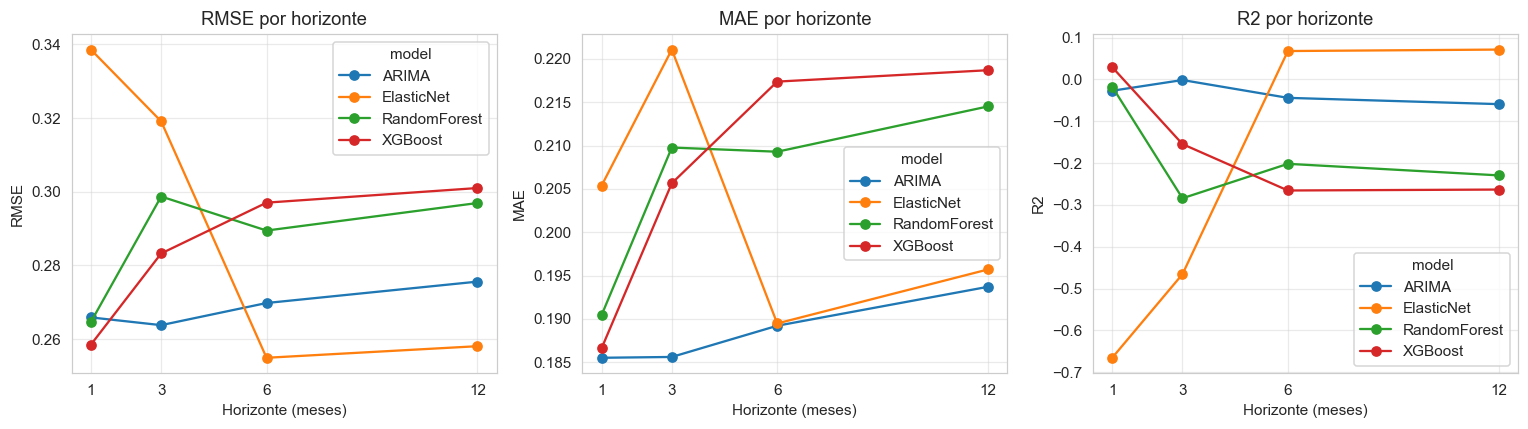

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
metric_names = ['RMSE', 'MAE', 'R2']

for ax, metric in zip(axes, metric_names):
    pivot = metrics_df.pivot(index='horizon', columns='model', values=metric)
    # Mantener orden consistente de modelos
    ordered = [m for m in ['ARIMA', 'ElasticNet', 'RandomForest', 'XGBoost'] if m in pivot.columns]
    pivot = pivot[ordered]
    pivot.plot(marker='o', ax=ax)
    ax.set_title(f"{metric} por horizonte")
    ax.set_xlabel("Horizonte (meses)")
    ax.set_ylabel(metric)
    ax.set_xticks(HORIZONS)
    ax.grid(alpha=0.4)

plt.tight_layout()
plt.savefig(PATH_FIGURES / 'modeling_01_metrics_by_horizon.png', dpi=120, bbox_inches='tight')
plt.show()

## 10. Análisis comparativo pre/post COVID

La pandemia introdujo un cambio estructural en la dinámica inflacionaria. Se recomputan las métricas segmentando las predicciones en dos regímenes:

- **Pre-COVID:** predicciones con fecha < marzo-2020.
- **Post-COVID:** predicciones con fecha ≥ marzo-2020.

Una caída fuerte del R² post-COVID indica que el modelo no generaliza al nuevo régimen.

In [10]:
def metrics_by_regime(predictions_df: pd.DataFrame, split_date: str) -> pd.DataFrame:
    split = pd.Timestamp(split_date)
    rows = []
    for (model, h), g in predictions_df.groupby(['model', 'horizon']):
        g_pre = g[g['date'] < split]
        g_post = g[g['date'] >= split]
        for regime, sub in [('pre_COVID', g_pre), ('post_COVID', g_post)]:
            if len(sub) == 0:
                continue
            rows.append({'model': model, 'horizon': h, 'regime': regime, 'n': len(sub), **compute_metrics(sub)})
    return pd.DataFrame(rows).sort_values(['horizon', 'regime', 'RMSE'])

regime_df = metrics_by_regime(predictions_df, COVID_SPLIT)
regime_df.to_csv(PATH_MODELS / 'metrics_pre_post_covid.csv', index=False)

print("MÉTRICAS PRE vs POST COVID-19\n" + '=' * 70)
print(regime_df.round(4).to_string(index=False))

MÉTRICAS PRE vs POST COVID-19
       model  horizon     regime   n   RMSE    MAE      R2
     XGBoost        1 post_COVID  70 0.2892 0.2071  0.1455
RandomForest        1 post_COVID  70 0.3114 0.2193  0.0093
       ARIMA        1 post_COVID  70 0.3506 0.2421 -0.2557
  ElasticNet        1 post_COVID  70 0.4941 0.3064 -1.4937
  ElasticNet        1  pre_COVID 110 0.1795 0.1411  0.1435
       ARIMA        1  pre_COVID 110 0.1936 0.1495  0.0040
RandomForest        1  pre_COVID 110 0.2300 0.1721 -0.4058
     XGBoost        1  pre_COVID 110 0.2369 0.1735 -0.4915
     XGBoost        3 post_COVID  68 0.3315 0.2499 -0.5145
       ARIMA        3 post_COVID  70 0.3375 0.2379 -0.1634
RandomForest        3 post_COVID  68 0.3578 0.2590 -0.7639
  ElasticNet        3 post_COVID  68 0.4146 0.2810 -1.3689
       ARIMA        3  pre_COVID 108 0.2022 0.1517 -0.0830
  ElasticNet        3  pre_COVID 110 0.2419 0.1840 -0.2174
     XGBoost        3  pre_COVID 110 0.2488 0.1783 -0.2876
RandomForest        3  pre

## 11. Predicho vs real para el mejor modelo en h=1

Mejor modelo para h=1: XGBoost (RMSE=0.2585)


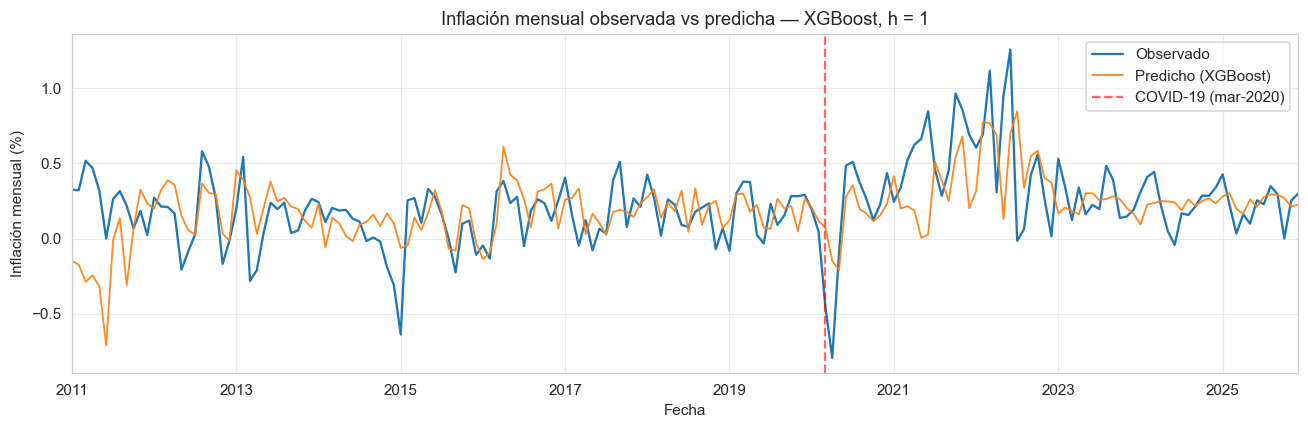

In [11]:
best_h1 = metrics_df[metrics_df['horizon'] == 1].sort_values('RMSE').iloc[0]
best_model_h1 = best_h1['model']
print(f"Mejor modelo para h=1: {best_model_h1} (RMSE={best_h1['RMSE']:.4f})")

df_plot = predictions_df[(predictions_df['model'] == best_model_h1) & (predictions_df['horizon'] == 1)].set_index('date').sort_index()

fig, ax = plt.subplots(figsize=(12, 4))
df_plot['y_true'].plot(ax=ax, label='Observado', linewidth=1.5)
df_plot['y_pred'].plot(ax=ax, label=f'Predicho ({best_model_h1})', linewidth=1.2, alpha=0.9)
ax.axvline(pd.Timestamp(COVID_SPLIT), color='red', linestyle='--', alpha=0.6, label='COVID-19 (mar-2020)')
ax.set_title(f"Inflación mensual observada vs predicha — {best_model_h1}, h = 1")
ax.set_ylabel("Inflación mensual (%)")
ax.set_xlabel("Fecha")
ax.legend()
ax.grid(alpha=0.4)
plt.tight_layout()
plt.savefig(PATH_FIGURES / 'modeling_02_pred_vs_obs_h1.png', dpi=120, bbox_inches='tight')
plt.show()

## 12. Análisis de residuos del mejor modelo h=1

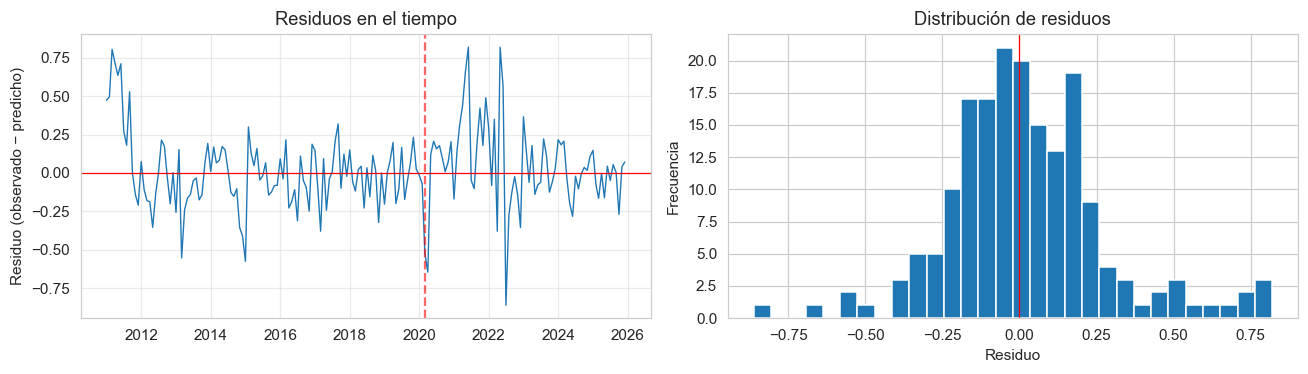

Media de residuos   : 0.0199
Std de residuos     : 0.2585
Residuo máx (abs)   : 0.8615  en 2022-07


In [12]:
residuals = df_plot['y_true'] - df_plot['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(12, 3.5))
axes[0].plot(residuals.index, residuals.values, linewidth=0.9)
axes[0].axhline(0, color='red', linewidth=0.8)
axes[0].axvline(pd.Timestamp(COVID_SPLIT), color='red', linestyle='--', alpha=0.6)
axes[0].set_title("Residuos en el tiempo")
axes[0].set_ylabel("Residuo (observado − predicho)")
axes[0].grid(alpha=0.4)

axes[1].hist(residuals, bins=30, edgecolor='white')
axes[1].axvline(0, color='red', linewidth=0.8)
axes[1].set_title("Distribución de residuos")
axes[1].set_xlabel("Residuo")
axes[1].set_ylabel("Frecuencia")

plt.tight_layout()
plt.savefig(PATH_FIGURES / 'modeling_03_residuals_h1.png', dpi=120, bbox_inches='tight')
plt.show()

print(f"Media de residuos   : {residuals.mean():.4f}")
print(f"Std de residuos     : {residuals.std():.4f}")
print(f"Residuo máx (abs)   : {residuals.abs().max():.4f}  en {residuals.abs().idxmax():%Y-%m}")

## 13. Persistencia: entrenar modelos finales sobre toda la historia

Para la app de Streamlit y para pronósticos futuros, se entrena cada modelo con **todos** los datos disponibles (sin dejar test set) y se persiste en disco. Esto maximiza la información utilizada para predecir los próximos meses.

Se guarda además el modelo ganador por horizonte según el RMSE en walk-forward.

In [13]:
best_per_horizon = {}
saved_models = []

for h in HORIZONS:
    Xh, yh = align_for_horizon(X_all, y_all, h)

    # Entrenar los 3 ML sobre el dataset completo y persistir
    for name, factory in ML_MODELS.items():
        model = factory()
        model.fit(Xh, yh)
        fname = f'best_{name}_h{h}.joblib'
        joblib.dump(model, PATH_MODELS / fname)
        saved_models.append(fname)

    # ARIMA entrenado sobre toda la serie (usa y_all entero para pronóstico h)
    arima_final = ARIMA(y_all, order=(1, 1, 1)).fit()
    joblib.dump(arima_final, PATH_MODELS / f'best_ARIMA_h{h}.joblib')
    saved_models.append(f'best_ARIMA_h{h}.joblib')

    # Identificar ganador por RMSE
    winner = metrics_df[metrics_df['horizon'] == h].sort_values('RMSE').iloc[0]
    best_per_horizon[str(h)] = {
        'model': winner['model'],
        'rmse':  float(winner['RMSE']),
        'mae':   float(winner['MAE']),
        'r2':    float(winner['R2']),
        'artifact': f"best_{winner['model']}_h{h}.joblib",
    }

with open(PATH_MODELS / 'best_model_per_horizon.json', 'w') as f:
    json.dump(best_per_horizon, f, indent=2)

print(f"Modelos guardados: {len(saved_models)}")
print(json.dumps(best_per_horizon, indent=2))

Modelos guardados: 16
{
  "1": {
    "model": "XGBoost",
    "rmse": 0.25851193895789015,
    "mae": 0.186606934643847,
    "r2": 0.02923852600300092,
    "artifact": "best_XGBoost_h1.joblib"
  },
  "3": {
    "model": "ARIMA",
    "rmse": 0.2638098740978471,
    "mae": 0.1856152874803191,
    "r2": -0.0015266667420645863,
    "artifact": "best_ARIMA_h3.joblib"
  },
  "6": {
    "model": "ElasticNet",
    "rmse": 0.25495481354836336,
    "mae": 0.18948019207130135,
    "r2": 0.06776304528843358,
    "artifact": "best_ElasticNet_h6.joblib"
  },
  "12": {
    "model": "ElasticNet",
    "rmse": 0.2580980812683297,
    "mae": 0.1957125769378491,
    "r2": 0.07125840157172425,
    "artifact": "best_ElasticNet_h12.joblib"
  }
}


## 14. Guardar predicciones walk-forward

In [14]:
predictions_df.to_csv(PATH_MODELS / 'walkforward_predictions.csv', index=False)
print(f"Predicciones guardadas en {PATH_MODELS / 'walkforward_predictions.csv'}")
print(f"Filas: {len(predictions_df)}")

Predicciones guardadas en /Users/javiermondragon/Documents/data_projects/inflation-predictor/models/walkforward_predictions.csv
Filas: 2808


## Resumen

**Configuración del experimento:**
- Ventana inicial de entrenamiento: feb-1993 → dic-2010 (≈216 observaciones).
- Evaluación out-of-sample: ene-2011 → dic-2025.
- Re-entrenamiento cada 6 meses; el modelo se mantiene fijo dentro del bloque.
- 4 modelos × 4 horizontes = 16 combinaciones evaluadas.

**Artefactos generados:**
- `models/walkforward_predictions.csv` — predicciones out-of-sample de cada modelo × horizonte.
- `models/metrics_by_horizon.csv` — RMSE / MAE / R² por combinación.
- `models/metrics_pre_post_covid.csv` — métricas segmentadas en mar-2020.
- `models/best_<modelo>_h<k>.joblib` — modelos re-entrenados con toda la historia.
- `models/best_model_per_horizon.json` — metadata del ganador por horizonte.
- `figures/modeling_01_metrics_by_horizon.png`, `modeling_02_pred_vs_obs_h1.png`, `modeling_03_residuals_h1.png`.

**Limitaciones y trabajo futuro:**
- Los hiperparámetros son defaults defendibles, no óptimos. Un grid-search con `TimeSeriesSplit` podría mejorar el desempeño marginal.
- ARIMA se fija en `(1,1,1)`; una búsqueda por AIC/BIC con `auto_arima` sería una mejora directa.
- La imputación forward-fill para CPI de oct-2025 genera una inflación observada de 0.0% en ese mes, que se incluye en la evaluación. Es una limitación heredada de los datos, no del modelo.

**Próximo paso:** `05_shap.ipynb` — interpretabilidad del mejor modelo (importancia global y explicación del pronóstico más reciente).